# Day 17: Pandas Time Series Handling
### Working with Dates and Temporal Data for AI and ML

**Day 17 of the 369-Day Python and AI Learning Path**

## Introduction: Why Time Series Matters in AI and ML

Time is one of the most valuable dimensions in real-world data. Unlike static datasets, time-based data carries sequence, context, and change over time. Those patterns help us uncover trends, seasonality, anomalies, and behavior shifts that are essential for accurate analysis and prediction.

Many practical datasets are built around time. E-commerce systems track customer activity across days and weeks, financial markets stream price movements continuously, IoT devices record sensor readings in real time, and healthcare platforms monitor patient signals around the clock. Without proper datetime handling, these signals can become messy, misleading, or even unusable.

Clean datetime processing helps prevent subtle but serious mistakes, such as misread date strings, timezone confusion, or accidental leakage of future data into training sets. It also unlocks powerful feature engineering opportunities, including hourly patterns, weekday effects, lag features, rolling statistics, and seasonality-aware signals.

In this notebook, you will learn how to use Pandas for practical time series handling, from basic datetime conversion to resampling, shifting, rolling windows, and machine learning feature creation. By the end, you will be able to transform raw timestamps into clear, useful, model-ready features.

## Table of Contents

1. [Converting Strings to Datetime](#converting-strings-to-datetime)
2. [Datetime Attributes (dt Accessor)](#datetime-attributes)
3. [Setting Datetime as the Index](#setting-datetime-as-index)
4. [Time-Based Indexing and Slicing](#time-based-indexing)
5. [Resampling: Upsampling and Downsampling](#resampling)
6. [Rolling and Expanding Windows](#rolling-windows)
7. [Shifting and Lagging Data](#shifting-data)
8. [Handling Time Zones](#time-zones)
9. [Time-Based Features for ML](#ml-features)
10. [Real AI and ML Examples](#ml-examples)
11. [Hands-On Exercises](#exercises)
12. [Solutions](#solutions)

## Converting Strings to Datetime {#converting-strings-to-datetime}

The first step in time series analysis is converting raw date strings into proper Pandas datetime objects. The pd.to_datetime() function is flexible, reliable, and able to interpret many common date formats.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Sample date strings in various formats
date_strings = ['2024-01-15', '2024-02-20', '2024-03-25', '2024-12-31']

# Convert to datetime
dates = pd.to_datetime(date_strings)
print("Converted dates:")
print(dates)
print(f"\nData type: {dates.dtype}")

# Handling different formats
mixed_dates = ['15/01/2024', '20-02-2024', 'March 25, 2024']
parsed_dates = pd.to_datetime(mixed_dates, format='mixed')
print("\nMixed format dates:")
print(parsed_dates)

Converted dates:
DatetimeIndex(['2024-01-15', '2024-02-20', '2024-03-25', '2024-12-31'], dtype='datetime64[us]', freq=None)

Data type: datetime64[us]

Mixed format dates:
DatetimeIndex(['2024-01-15', '2024-02-20', '2024-03-25'], dtype='datetime64[us]', freq=None)


## Datetime Attributes (dt Accessor) {#datetime-attributes}

Once your data is in datetime format, the .dt accessor gives you direct access to useful components such as year, month, day, weekday, hour, and more. These extracted values are especially helpful for feature engineering in machine learning workflows.

In [53]:
date_range = pd.date_range(start='2024-01-01', periods=5, freq='D')
df = pd.DataFrame({'datetime': date_range})

# Extract various datetime components
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['weekday'] = df['datetime'].dt.weekday  # 0=Monday, 6=Sunday
df['day_name'] = df['datetime'].dt.day_name()
df['quarter'] = df['datetime'].dt.quarter
df['is_month_start'] = df['datetime'].dt.is_month_start

print("Datetime attributes:")
print(df)

# Create a time series with hours for more examples
hourly_data = pd.date_range('2024-01-01', periods=24, freq='h')
df_hourly = pd.DataFrame({'datetime': hourly_data})
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['date'] = df_hourly['datetime'].dt.date
df_hourly['time'] = df_hourly['datetime'].dt.time

print("\nHourly data extraction:")
print(df_hourly.head(10))

Datetime attributes:
    datetime  year  month  day  weekday   day_name  quarter  is_month_start
0 2024-01-01  2024      1    1        0     Monday        1            True
1 2024-01-02  2024      1    2        1    Tuesday        1           False
2 2024-01-03  2024      1    3        2  Wednesday        1           False
3 2024-01-04  2024      1    4        3   Thursday        1           False
4 2024-01-05  2024      1    5        4     Friday        1           False

Hourly data extraction:
             datetime  hour        date      time
0 2024-01-01 00:00:00     0  2024-01-01  00:00:00
1 2024-01-01 01:00:00     1  2024-01-01  01:00:00
2 2024-01-01 02:00:00     2  2024-01-01  02:00:00
3 2024-01-01 03:00:00     3  2024-01-01  03:00:00
4 2024-01-01 04:00:00     4  2024-01-01  04:00:00
5 2024-01-01 05:00:00     5  2024-01-01  05:00:00
6 2024-01-01 06:00:00     6  2024-01-01  06:00:00
7 2024-01-01 07:00:00     7  2024-01-01  07:00:00
8 2024-01-01 08:00:00     8  2024-01-01  08:00:0

## Setting Datetime as the Index {#setting-datetime-as-index}

Using a datetime column as the DataFrame index makes time series work far more natural. It enables fast slicing, resampling, rolling calculations, and other time-aware operations that are central to effective analysis.

DataFrame with DatetimeIndex:
                  sales  customers
date                              
2023-01-01  1004.967142         18
2023-01-02  1007.024814         21
2023-01-03  1016.940996         20
2023-01-04  1035.608556         21
2023-01-05  1036.701230         16
2023-01-06  1037.790000         20
2023-01-07  1057.007183         23
2023-01-08  1068.100488         28
2023-01-09  1066.817592         26
2023-01-10  1075.646921         32

Index type: <class 'pandas.DatetimeIndex'>


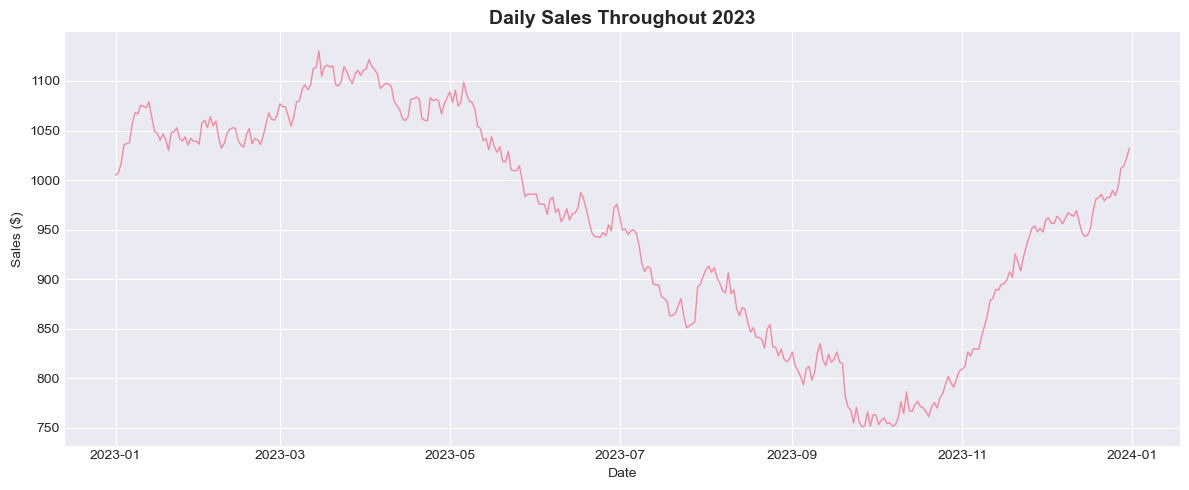

In [54]:
# Create synthetic daily sales data
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
sales = 1000 + np.cumsum(np.random.randn(len(dates)) * 10) + np.sin(np.arange(len(dates)) * 2 * np.pi / 365.25) * 200

# Create DataFrame and set datetime index
df_sales = pd.DataFrame({
    'date': dates,
    'sales': sales,
    'customers': (sales / 50 + np.random.randn(len(dates)) * 5).astype(int)
})

# Set date as index
df_sales.set_index('date', inplace=True)
print("DataFrame with DatetimeIndex:")
print(df_sales.head(10))
print(f"\nIndex type: {type(df_sales.index)}")

# Quick visualization
plt.figure(figsize=(12, 5))
plt.plot(df_sales.index, df_sales['sales'], linewidth=1, alpha=0.8)
plt.title('Daily Sales Throughout 2023', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()


## Time-Based Indexing and Slicing {#time-based-indexing}

With a DatetimeIndex, you can filter data using intuitive date strings instead of writing long boolean conditions. This makes time-based exploration cleaner, faster, and much easier to read.

Sales in January 2023:
                  sales  customers
2023-01-01  1000.195845         19
2023-01-02   999.217472         15
2023-01-03   999.625725         31
2023-01-04   997.923142         33
2023-01-05   998.952297         28

Sales from March to May 2023:
Shape: (92, 2)
                  sales  customers
2023-03-01  1003.622231         15
2023-03-02  1004.051849         23
2023-03-03  1004.259537         30
2023-03-04  1004.531116         27
2023-03-05  1003.254367         23

Sales on specific date:
sales        1032.149507
customers      18.000000
Name: 2023-07-04 00:00:00, dtype: float64

Sales after June 2023:
                  sales  customers
2023-06-01  1015.820311         16
2023-06-02  1015.330872         31
2023-06-03  1016.375033         27
2023-06-04  1017.056924         18
2023-06-05  1018.903631         25


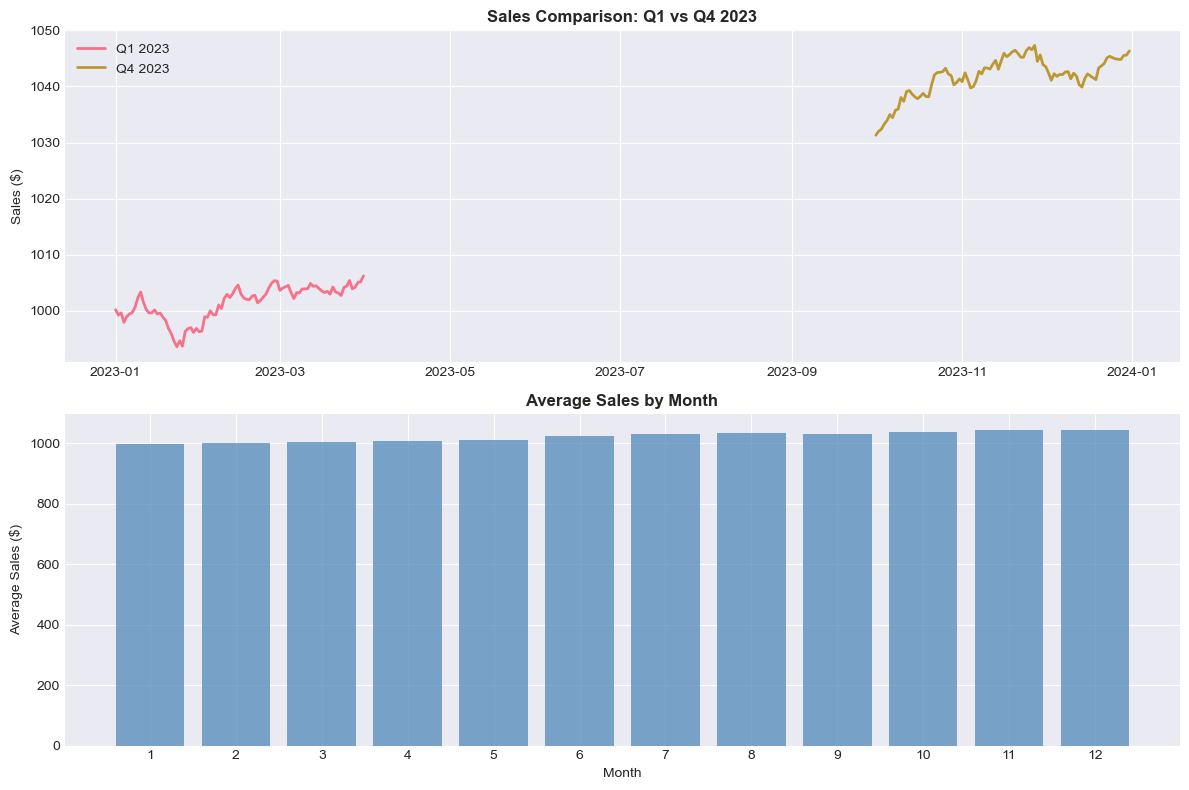

In [55]:
# Time-based slicing examples
# Create a larger dataset for the year
date_range = pd.date_range(start='2023-01-01', periods=365, freq='D')
df_sales = pd.DataFrame({'sales': np.random.randn(365).cumsum() + 1000, 'customers': np.random.randint(15, 35, 365)}, index=date_range)

print("Sales in January 2023:")
print(df_sales.loc['2023-01'].head())

print("\nSales from March to May 2023:")
spring_sales = df_sales.loc['2023-03':'2023-05']
print(f"Shape: {spring_sales.shape}")
print(spring_sales.head())

print("\nSales on specific date:")
print(df_sales.loc['2023-07-04'])

# Using truncate for before/after
print("\nSales after June 2023:")
print(df_sales.truncate(before='2023-06-01').head())

# Visualization of sliced data
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Q1 vs Q4
q1_data = df_sales.loc['2023-01':'2023-03']
q4_data = df_sales.loc['2023-10':'2023-12']

axes[0].plot(q1_data.index, q1_data['sales'], label='Q1 2023', linewidth=2)
axes[0].plot(q4_data.index, q4_data['sales'], label='Q4 2023', linewidth=2)
axes[0].set_title('Sales Comparison: Q1 vs Q4 2023', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Sales ($)')

# Monthly pattern
monthly_avg = df_sales.groupby(df_sales.index.month)['sales'].mean()
axes[1].bar(monthly_avg.index, monthly_avg.values, color='steelblue', alpha=0.7)
axes[1].set_title('Average Sales by Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Sales ($)')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Resampling (Upsampling and Downsampling) {#resampling}

Resampling changes the frequency of a time series. Downsampling aggregates data to a lower frequency, such as converting daily data into monthly summaries. Upsampling increases the frequency, such as moving from daily data to hourly intervals, and often requires filling or interpolation.

**Common frequency aliases:**
- D = Daily
- W = Weekly
- M = Month end
- MS = Month start
- Q = Quarter end
- Y = Year end
- H = Hourly
- T or min = Minute

Monthly aggregated sales:
                   sales  customers
2023-01-31  30947.080298        808
2023-02-28  28056.060967        686
2023-03-31  31122.740224        738
2023-04-30  30256.856705        693
2023-05-31  31350.546655        810

Weekly average sales:
                  sales  customers
2023-01-01  1000.195845  19.000000
2023-01-08   999.355439  27.285714
2023-01-15  1000.966079  25.714286
2023-01-22   997.627551  29.000000
2023-01-29   995.449418  23.857143

Quarterly statistics:
                  sales                                     customers
                   mean       std          min          max       sum
2023-03-31  1001.398683  3.066044   993.578610  1006.211093      2232
2023-06-30  1014.613106  7.381161  1005.693805  1030.506593      2223
2023-09-30  1031.804191  2.398363  1027.136840  1037.832047      2117
2023-12-31  1041.769911  3.588265  1031.313455  1047.329336      2240

Upsampled temperature (first 24 hours):
                     temperature
2024-01-

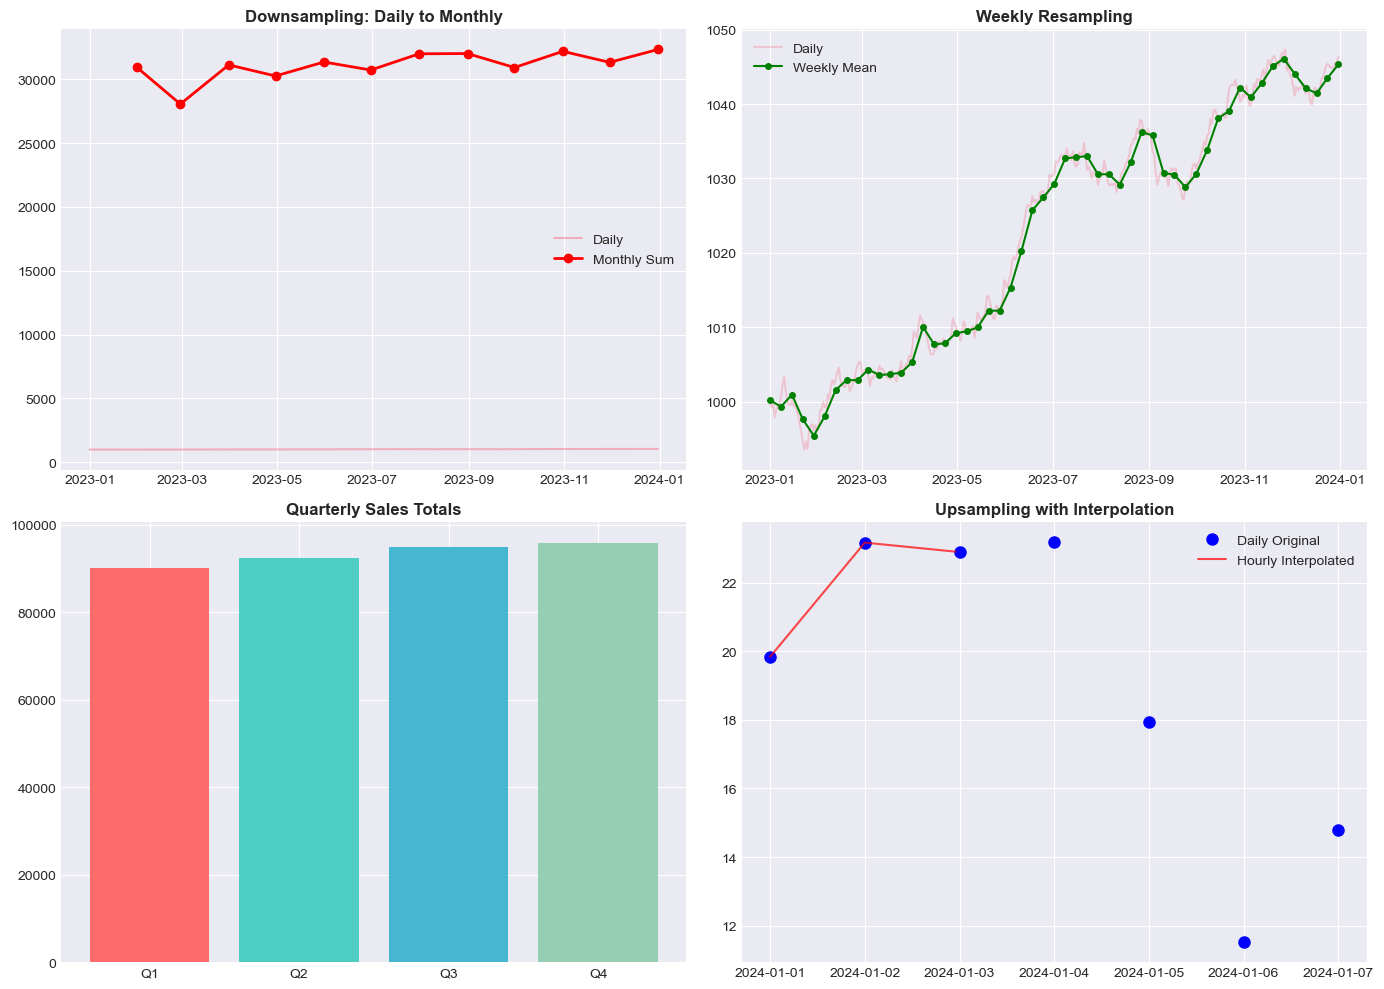

In [56]:
# Downsampling: Daily to Monthly
monthly_sales = df_sales.resample('ME').agg({
    'sales': 'sum',
    'customers': 'sum'
})
print("Monthly aggregated sales:")
print(monthly_sales.head())

# Weekly resampling
weekly_sales = df_sales.resample('W').mean()
print("\nWeekly average sales:")
print(weekly_sales.head())

# Quarterly with custom aggregation
quarterly_stats = df_sales.resample('QE').agg({
    'sales': ['mean', 'std', 'min', 'max'],
    'customers': 'sum'
})
print("\nQuarterly statistics:")
print(quarterly_stats.head())

# Upsampling example (hourly from daily - requires interpolation)
daily_temp = pd.DataFrame({
    'temperature': 20 + 5 * np.sin(np.arange(7) * 2 * np.pi / 7) + np.random.randn(7) * 2
}, index=pd.date_range('2024-01-01', periods=7, freq='D'))

# Upsample to hourly and interpolate
hourly_temp = daily_temp.resample('h').interpolate(method='linear')
print("\nUpsampled temperature (first 24 hours):")
print(hourly_temp.head(24))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original daily data
axes[0,0].plot(df_sales.index, df_sales['sales'], alpha=0.5, label='Daily')
axes[0,0].plot(monthly_sales.index, monthly_sales['sales'], 'ro-', linewidth=2, label='Monthly Sum')
axes[0,0].set_title('Downsampling: Daily to Monthly', fontweight='bold')
axes[0,0].legend()

# Weekly rolling
axes[0,1].plot(df_sales.index, df_sales['sales'], alpha=0.3, label='Daily')
axes[0,1].plot(weekly_sales.index, weekly_sales['sales'], 'go-', markersize=4, label='Weekly Mean')
axes[0,1].set_title('Weekly Resampling', fontweight='bold')
axes[0,1].legend()

# Quarterly aggregation
quarterly_sales = df_sales.resample('QE')['sales'].sum()
axes[1,0].bar(range(len(quarterly_sales)), quarterly_sales.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[1,0].set_title('Quarterly Sales Totals', fontweight='bold')
axes[1,0].set_xticks(range(len(quarterly_sales)))
axes[1,0].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

# Upsampling visualization
axes[1,1].plot(daily_temp.index, daily_temp['temperature'], 'bo', markersize=8, label='Daily Original')
axes[1,1].plot(hourly_temp.index[:48], hourly_temp['temperature'][:48], 'r-', alpha=0.7, label='Hourly Interpolated')
axes[1,1].set_title('Upsampling with Interpolation', fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## Rolling and Expanding Windows {#rolling-windows}

Rolling windows compute statistics over a moving subset of observations. They are useful for smoothing noise, identifying short-term trends, and creating features that capture recent behavior.

- .rolling(window=7) creates a 7-period rolling window.
- .expanding() creates a growing window from the beginning up to the current row.

Data with rolling statistics:
                  sales  sales_7d_mean  sales_30d_mean  sales_7d_std
2023-01-01  1000.195845            NaN             NaN           NaN
2023-01-02   999.217472            NaN             NaN           NaN
2023-01-03   999.625725            NaN             NaN           NaN
2023-01-04   997.923142            NaN             NaN           NaN
2023-01-05   998.952297            NaN             NaN           NaN
2023-01-06   999.424895            NaN             NaN           NaN
2023-01-07   999.680924     999.288614             NaN      0.717853
2023-01-08  1000.663615     999.355439             NaN      0.829476
2023-01-09  1002.329090     999.799956             NaN      1.388559
2023-01-10  1003.343460    1000.331060             NaN      1.920075
2023-01-11  1001.502586    1000.842410             NaN      1.626048
2023-01-12  1000.223009    1001.023940             NaN      1.440177
2023-01-13   999.598190    1001.048696             NaN      1.409266
2023

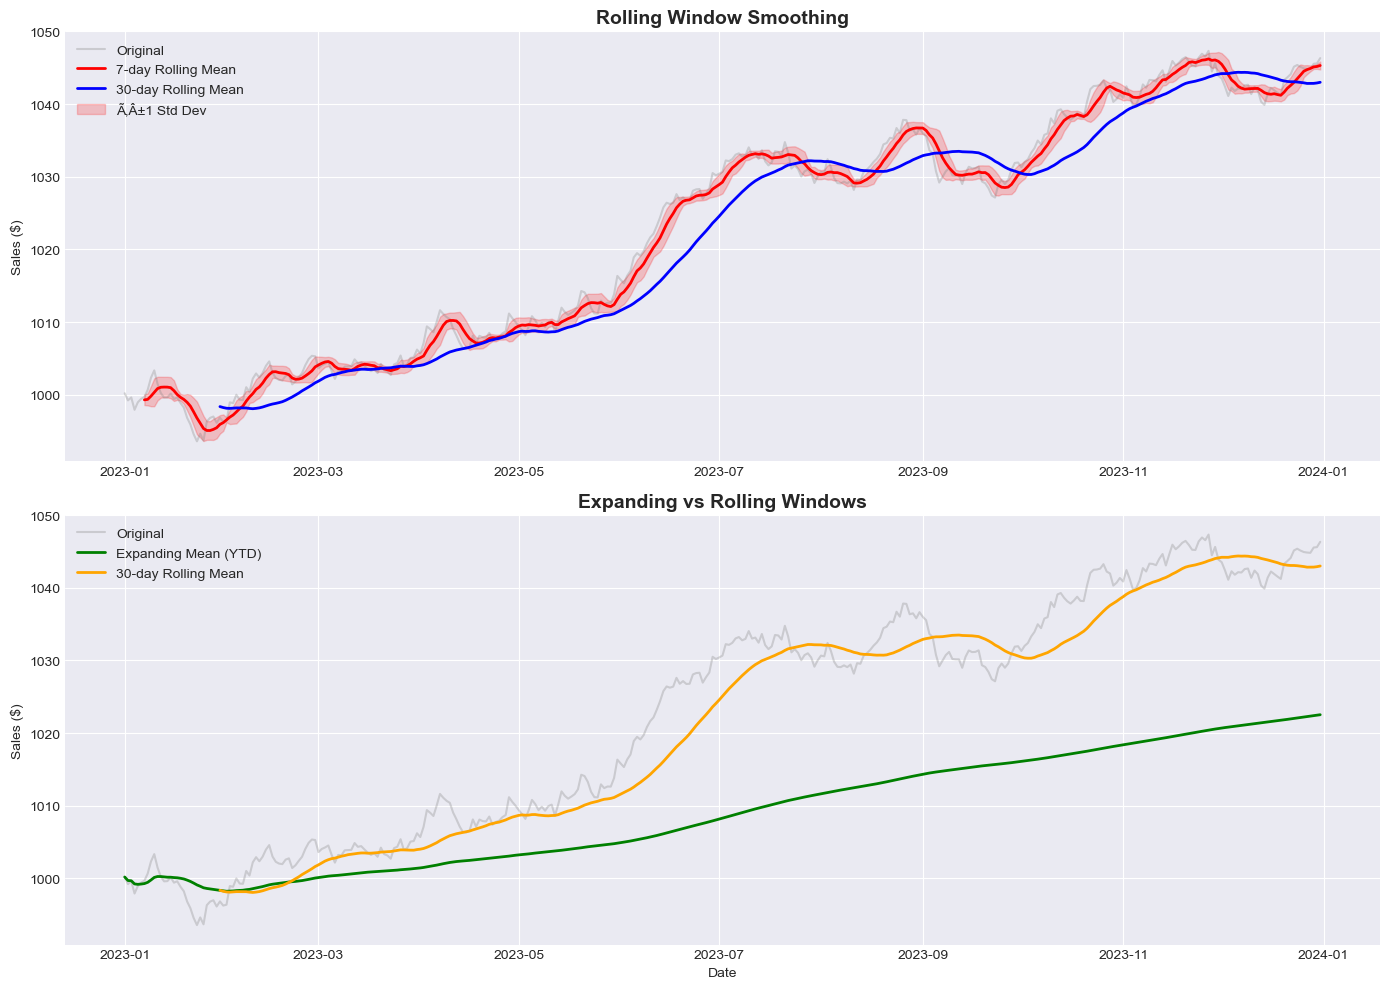

In [57]:
# Rolling window calculations
df_sales['sales_7d_mean'] = df_sales['sales'].rolling(window=7).mean()
df_sales['sales_30d_mean'] = df_sales['sales'].rolling(window=30).mean()
df_sales['sales_7d_std'] = df_sales['sales'].rolling(window=7).std()

# Expanding window (cumulative statistics)
df_sales['sales_expanding_mean'] = df_sales['sales'].expanding().mean()
df_sales['sales_cumsum'] = df_sales['sales'].expanding().sum()

# Centered rolling (for smoothing, uses past and future)
df_sales['sales_centered'] = df_sales['sales'].rolling(window=7, center=True).mean()

print("Data with rolling statistics:")
print(df_sales[['sales', 'sales_7d_mean', 'sales_30d_mean', 'sales_7d_std']].head(35))

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Rolling means
axes[0].plot(df_sales.index, df_sales['sales'], alpha=0.3, color='gray', label='Original')
axes[0].plot(df_sales.index, df_sales['sales_7d_mean'], color='red', linewidth=2, label='7-day Rolling Mean')
axes[0].plot(df_sales.index, df_sales['sales_30d_mean'], color='blue', linewidth=2, label='30-day Rolling Mean')
axes[0].fill_between(df_sales.index, 
                     df_sales['sales_7d_mean'] - df_sales['sales_7d_std'],
                     df_sales['sales_7d_mean'] + df_sales['sales_7d_std'],
                     alpha=0.2, color='red', label='Ã‚Â±1 Std Dev')
axes[0].set_title('Rolling Window Smoothing', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Sales ($)')

# Expanding vs Rolling
axes[1].plot(df_sales.index, df_sales['sales'], alpha=0.3, color='gray', label='Original')
axes[1].plot(df_sales.index, df_sales['sales_expanding_mean'], color='green', linewidth=2, label='Expanding Mean (YTD)')
axes[1].plot(df_sales.index, df_sales['sales_30d_mean'], color='orange', linewidth=2, label='30-day Rolling Mean')
axes[1].set_title('Expanding vs Rolling Windows', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].set_ylabel('Sales ($)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


## Shifting and Lagging Data {#shifting-data}

The .shift() method moves values forward or backward relative to time. It is widely used to create lag features, which help models learn from previous observations when predicting future values.

Data with lag features:
                  sales  sales_lag_1d  sales_lag_7d  sales_change  \
2023-01-01  1000.195845           NaN           NaN           NaN   
2023-01-02   999.217472   1000.195845           NaN     -0.978373   
2023-01-03   999.625725    999.217472           NaN      0.408253   
2023-01-04   997.923142    999.625725           NaN     -1.702584   
2023-01-05   998.952297    997.923142           NaN      1.029156   
2023-01-06   999.424895    998.952297           NaN      0.472597   
2023-01-07   999.680924    999.424895           NaN      0.256030   
2023-01-08  1000.663615    999.680924   1000.195845      0.982691   
2023-01-09  1002.329090   1000.663615    999.217472      1.665474   
2023-01-10  1003.343460   1002.329090    999.625725      1.014370   

            sales_pct_change  
2023-01-01               NaN  
2023-01-02         -0.097818  
2023-01-03          0.040857  
2023-01-04         -0.170322  
2023-01-05          0.103130  
2023-01-06          0.047309  

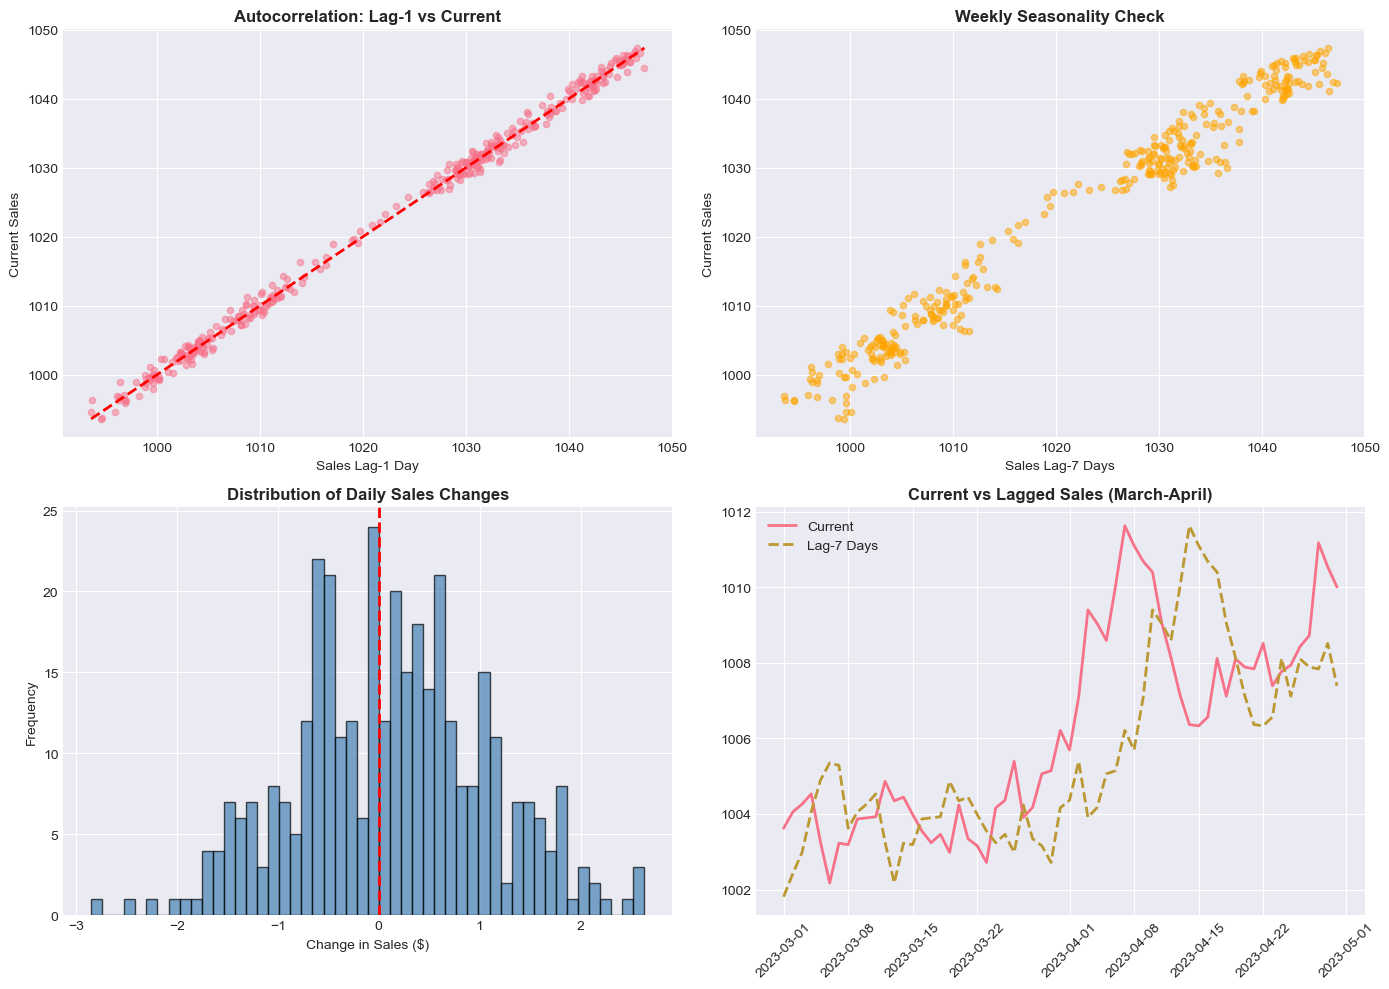

In [58]:
# Shifting data to create lag features
df_sales['sales_lag_1d'] = df_sales['sales'].shift(1)  # Previous day
df_sales['sales_lag_7d'] = df_sales['sales'].shift(7)  # Same day last week
df_sales['sales_lag_30d'] = df_sales['sales'].shift(30)  # Same day last month

# Forward shift (moving data to past)
df_sales['sales_lead_1d'] = df_sales['sales'].shift(-1)  # Next day (target for prediction)

# Calculate daily change
df_sales['sales_change'] = df_sales['sales'] - df_sales['sales_lag_1d']
df_sales['sales_pct_change'] = df_sales['sales'].pct_change() * 100

# Difference with same day last week (weekly seasonality)
df_sales['sales_weekly_diff'] = df_sales['sales'] - df_sales['sales_lag_7d']

print("Data with lag features:")
print(df_sales[['sales', 'sales_lag_1d', 'sales_lag_7d', 'sales_change', 'sales_pct_change']].head(10))

# Correlation analysis
correlations = df_sales[['sales', 'sales_lag_1d', 'sales_lag_7d', 'sales_lag_30d']].corr()
print("\nCorrelation matrix:")
print(correlations)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Lag-1 scatter plot
axes[0,0].scatter(df_sales['sales_lag_1d'], df_sales['sales'], alpha=0.5, s=20)
axes[0,0].plot([df_sales['sales'].min(), df_sales['sales'].max()], 
               [df_sales['sales'].min(), df_sales['sales'].max()], 'r--', lw=2)
axes[0,0].set_xlabel('Sales Lag-1 Day')
axes[0,0].set_ylabel('Current Sales')
axes[0,0].set_title('Autocorrelation: Lag-1 vs Current', fontweight='bold')

# Weekly pattern
weekly_corr = df_sales[['sales', 'sales_lag_7d']].dropna()
axes[0,1].scatter(weekly_corr['sales_lag_7d'], weekly_corr['sales'], alpha=0.5, s=20, color='orange')
axes[0,1].set_xlabel('Sales Lag-7 Days')
axes[0,1].set_ylabel('Current Sales')
axes[0,1].set_title('Weekly Seasonality Check', fontweight='bold')

# Daily changes distribution
axes[1,0].hist(df_sales['sales_change'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1,0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_title('Distribution of Daily Sales Changes', fontweight='bold')
axes[1,0].set_xlabel('Change in Sales ($)')
axes[1,0].set_ylabel('Frequency')

# Time series with lag
sample_period = df_sales['2023-03':'2023-04']
axes[1,1].plot(sample_period.index, sample_period['sales'], label='Current', linewidth=2)
axes[1,1].plot(sample_period.index, sample_period['sales_lag_7d'], label='Lag-7 Days', linewidth=2, linestyle='--')
axes[1,1].set_title('Current vs Lagged Sales (March-April)', fontweight='bold')
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Handling Time Zones {#time-zones}

Time zones become essential as soon as your data comes from multiple regions. Pandas provides 	z_localize() to assign a timezone to naive timestamps and 	z_convert() to convert aware timestamps between regions.

In [59]:
naive_dates = pd.date_range('2024-01-01', periods=5, freq='h')
df_tz = pd.DataFrame({'timestamp': naive_dates, 'value': range(5)})

# Localize to UTC
df_tz['timestamp_utc'] = df_tz['timestamp'].dt.tz_localize('UTC')

# Convert to different time zones
df_tz['timestamp_ny'] = df_tz['timestamp_utc'].dt.tz_convert('America/New_York')
df_tz['timestamp_tokyo'] = df_tz['timestamp_utc'].dt.tz_convert('Asia/Tokyo')
df_tz['timestamp_london'] = df_tz['timestamp_utc'].dt.tz_convert('Europe/London')

print("Time zone conversions:")
print(df_tz[['timestamp_utc', 'timestamp_ny', 'timestamp_tokyo', 'timestamp_london']])

# Practical example: Global event timestamps
events = pd.DataFrame({
    'event': ['Login', 'Purchase', 'Logout', 'Login', 'Purchase'],
    'timestamp_utc': pd.to_datetime([
        '2024-01-15 08:00:00', '2024-01-15 08:30:00', '2024-01-15 09:00:00',
        '2024-01-15 14:00:00', '2024-01-15 14:45:00'
    ]).tz_localize('UTC')
})

events['timestamp_local'] = events['timestamp_utc'].dt.tz_convert('America/Los_Angeles')
events['hour_utc'] = events['timestamp_utc'].dt.hour
events['hour_local'] = events['timestamp_local'].dt.hour

print("\nGlobal event tracking:")
print(events[['event', 'timestamp_utc', 'timestamp_local', 'hour_utc', 'hour_local']])

# Remove timezone info
events['timestamp_naive'] = events['timestamp_utc'].dt.tz_localize(None)
print("\nAfter removing timezone:")
print(events['timestamp_naive'])

Time zone conversions:
              timestamp_utc              timestamp_ny  \
0 2024-01-01 00:00:00+00:00 2023-12-31 19:00:00-05:00   
1 2024-01-01 01:00:00+00:00 2023-12-31 20:00:00-05:00   
2 2024-01-01 02:00:00+00:00 2023-12-31 21:00:00-05:00   
3 2024-01-01 03:00:00+00:00 2023-12-31 22:00:00-05:00   
4 2024-01-01 04:00:00+00:00 2023-12-31 23:00:00-05:00   

            timestamp_tokyo          timestamp_london  
0 2024-01-01 09:00:00+09:00 2024-01-01 00:00:00+00:00  
1 2024-01-01 10:00:00+09:00 2024-01-01 01:00:00+00:00  
2 2024-01-01 11:00:00+09:00 2024-01-01 02:00:00+00:00  
3 2024-01-01 12:00:00+09:00 2024-01-01 03:00:00+00:00  
4 2024-01-01 13:00:00+09:00 2024-01-01 04:00:00+00:00  

Global event tracking:
      event             timestamp_utc           timestamp_local  hour_utc  \
0     Login 2024-01-15 08:00:00+00:00 2024-01-15 00:00:00-08:00         8   
1  Purchase 2024-01-15 08:30:00+00:00 2024-01-15 00:30:00-08:00         8   
2    Logout 2024-01-15 09:00:00+00:00 2024-

## Time-Based Features for ML {#ml-features}

Well-designed time-based features can significantly improve model performance. They help capture recurring behavior, seasonal structure, calendar effects, and cyclical patterns that raw timestamps do not express on their own.

ML-ready time features:
             datetime  energy_consumption  year  month  day  hour  minute  \
0 2023-01-01 00:00:00          102.827602  2023      1    1     0       0   
1 2023-01-01 01:00:00          107.417281  2023      1    1     1       0   
2 2023-01-01 02:00:00          118.582474  2023      1    1     2       0   
3 2023-01-01 03:00:00          129.172384  2023      1    1     3       0   
4 2023-01-01 04:00:00          125.154027  2023      1    1     4       0   

   weekday  weekofyear  is_weekend  ...  is_month_end  quarter  season  \
0        6          52           1  ...             0        1       1   
1        6          52           1  ...             0        1       1   
2        6          52           1  ...             0        1       1   
3        6          52           1  ...             0        1       1   
4        6          52           1  ...             0        1       1   

   hour_sin  hour_cos  month_sin  month_cos  weekday_sin  weekday_co

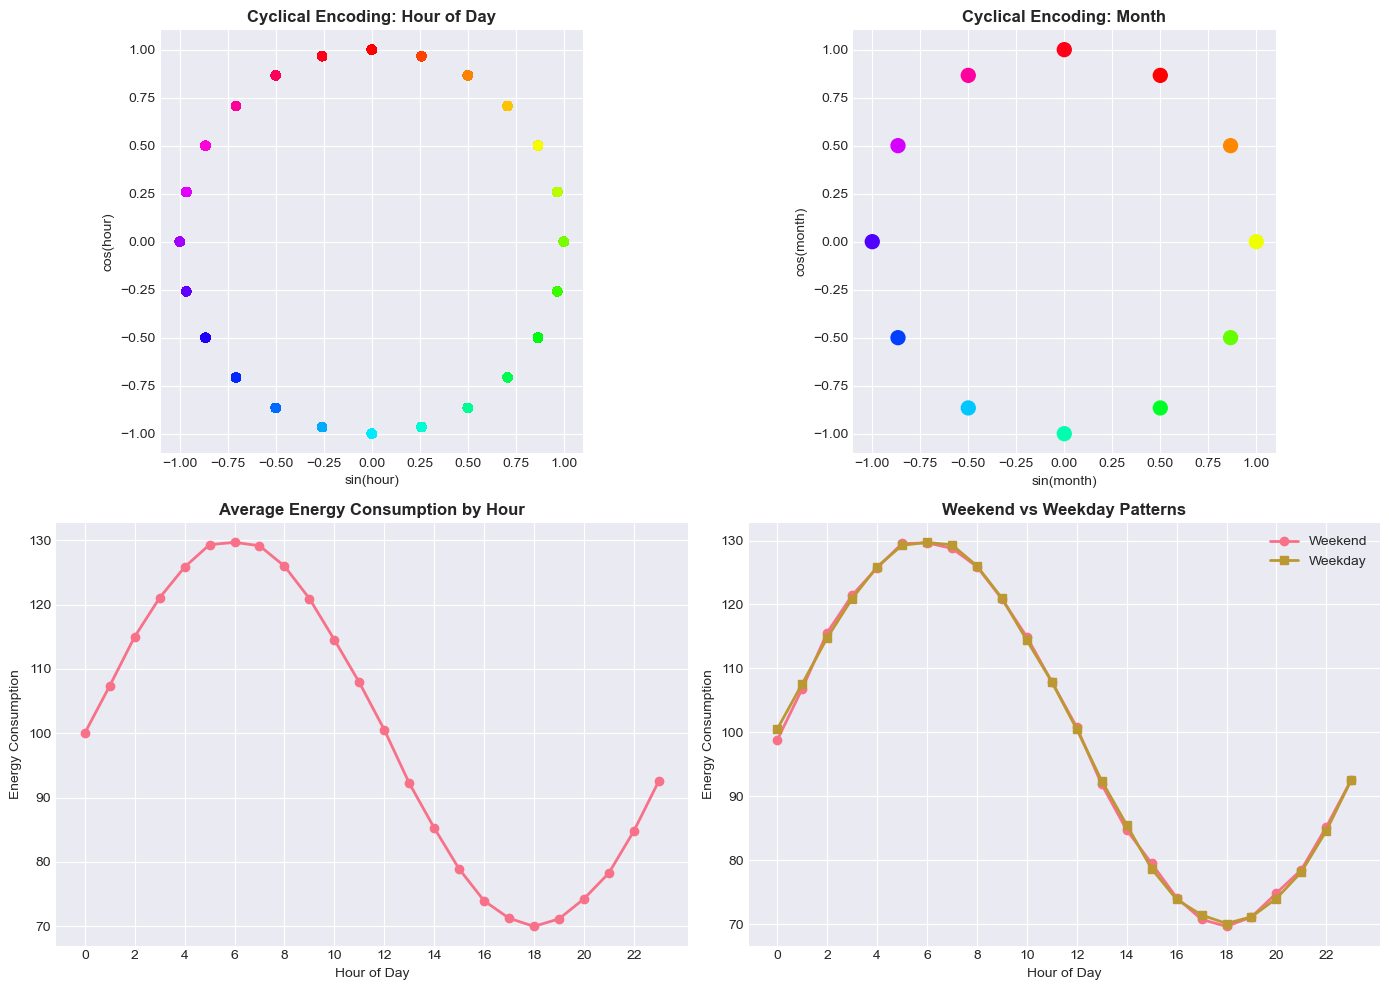

In [60]:
# Create comprehensive time-based features
def create_time_features(df, datetime_col):
    """Extract comprehensive time-based features for ML"""
    df = df.copy()
    
    # Basic components
    df['year'] = df[datetime_col].dt.year
    df['month'] = df[datetime_col].dt.month
    df['day'] = df[datetime_col].dt.day
    df['hour'] = df[datetime_col].dt.hour
    df['minute'] = df[datetime_col].dt.minute
    
    # Week-based features
    df['weekday'] = df[datetime_col].dt.weekday  # 0=Monday
    df['weekofyear'] = df[datetime_col].dt.isocalendar().week
    df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
    df['is_month_start'] = df[datetime_col].dt.is_month_start.astype(int)
    df['is_month_end'] = df[datetime_col].dt.is_month_end.astype(int)
    
    # Quarter and season
    df['quarter'] = df[datetime_col].dt.quarter
    df['season'] = df['month'] % 12 // 3 + 1  # 1=Winter, 2=Spring, 3=Summer, 4=Fall
    
    # Cyclical encoding (preserves circular nature of time)
    # For hour: 23 and 0 should be close, not far apart
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)
    
    # Day of year (for yearly seasonality)
    df['dayofyear'] = df[datetime_col].dt.dayofyear
    
    return df

# Apply to hourly data
np.random.seed(42)
hourly_dates = pd.date_range('2023-01-01', periods=8760, freq='h')  # Full year
hourly_df = pd.DataFrame({
    'datetime': hourly_dates,
    'energy_consumption': 100 + 30 * np.sin(2 * np.pi * hourly_dates.hour / 24) + 
                          20 * np.sin(2 * np.pi * hourly_dates.dayofyear / 365.25) + 
                          np.random.randn(8760) * 5
})

hourly_df = create_time_features(hourly_df, 'datetime')
print("ML-ready time features:")
print(hourly_df.head())

# Visualize cyclical encoding
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hour cyclical encoding
axes[0,0].scatter(hourly_df['hour_sin'], hourly_df['hour_cos'], c=hourly_df['hour'], cmap='hsv', alpha=0.5)
axes[0,0].set_title('Cyclical Encoding: Hour of Day', fontweight='bold')
axes[0,0].set_xlabel('sin(hour)')
axes[0,0].set_ylabel('cos(hour)')
axes[0,0].set_aspect('equal')

# Month cyclical encoding
monthly_sample = hourly_df.drop_duplicates('month')
axes[0,1].scatter(monthly_sample['month_sin'], monthly_sample['month_cos'], 
                  c=monthly_sample['month'], cmap='hsv', s=100)
axes[0,1].set_title('Cyclical Encoding: Month', fontweight='bold')
axes[0,1].set_xlabel('sin(month)')
axes[0,1].set_ylabel('cos(month)')
axes[0,1].set_aspect('equal')

# Energy by hour
hourly_avg = hourly_df.groupby('hour')['energy_consumption'].mean()
axes[1,0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, markersize=6)
axes[1,0].set_title('Average Energy Consumption by Hour', fontweight='bold')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Energy Consumption')
axes[1,0].set_xticks(range(0, 24, 2))

# Weekend vs Weekday pattern
weekend_pattern = hourly_df[hourly_df['is_weekend'] == 1].groupby('hour')['energy_consumption'].mean()
weekday_pattern = hourly_df[hourly_df['is_weekend'] == 0].groupby('hour')['energy_consumption'].mean()
axes[1,1].plot(weekend_pattern.index, weekend_pattern.values, label='Weekend', linewidth=2, marker='o')
axes[1,1].plot(weekday_pattern.index, weekday_pattern.values, label='Weekday', linewidth=2, marker='s')
axes[1,1].set_title('Weekend vs Weekday Patterns', fontweight='bold')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Energy Consumption')
axes[1,1].legend()
axes[1,1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()


## Real AI and ML Examples {#ml-examples}

Now let us bring the ideas together with practical preprocessing examples. In this section, you will build lag features, rolling statistics, and clean time-aware train/validation splits for machine learning workflows.

In [61]:
# Example 1: Creating comprehensive feature set for sales forecasting
def create_ml_features(df, target_col='sales'):
    """Create ML-ready features from time series"""
    df = df.copy()
    
    # Lag features (past values as predictors)
    for lag in [1, 7, 14, 30]:
        df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    
    # Rolling statistics (trends and volatility)
    for window in [7, 14, 30]:
        df[f'{target_col}_rolling_mean_{window}'] = df[target_col].rolling(window=window).mean()
        df[f'{target_col}_rolling_std_{window}'] = df[target_col].rolling(window=window).std()
        df[f'{target_col}_rolling_min_{window}'] = df[target_col].rolling(window=window).min()
        df[f'{target_col}_rolling_max_{window}'] = df[target_col].rolling(window=window).max()
    
    # Expanding statistics (long-term trends)
    df[f'{target_col}_expanding_mean'] = df[target_col].expanding().mean()
    
    # Rate of change
    df[f'{target_col}_pct_change'] = df[target_col].pct_change()
    df[f'{target_col}_diff_7'] = df[target_col].diff(7)  # Weekly difference
    
    # Time-based features
    df['month'] = df.index.month
    df['weekday'] = df.index.weekday
    df['is_weekend'] = (df.index.weekday >= 5).astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
    
    return df

# Apply feature engineering
df_ml = create_ml_features(df_sales)
print("ML feature set shape:", df_ml.shape)
print("\nFeature columns:")
feature_cols = [c for c in df_ml.columns if c not in ['sales']]
print(feature_cols)

# Show sample
print("\nSample of engineered features:")
print(df_ml[['sales', 'sales_lag_1', 'sales_lag_7', 'sales_rolling_mean_7', 'sales_rolling_std_30', 'is_weekend']].head(35))


ML feature set shape: (365, 37)

Feature columns:
['customers', 'sales_7d_mean', 'sales_30d_mean', 'sales_7d_std', 'sales_expanding_mean', 'sales_cumsum', 'sales_centered', 'sales_lag_1d', 'sales_lag_7d', 'sales_lag_30d', 'sales_lead_1d', 'sales_change', 'sales_pct_change', 'sales_weekly_diff', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 'sales_rolling_mean_7', 'sales_rolling_std_7', 'sales_rolling_min_7', 'sales_rolling_max_7', 'sales_rolling_mean_14', 'sales_rolling_std_14', 'sales_rolling_min_14', 'sales_rolling_max_14', 'sales_rolling_mean_30', 'sales_rolling_std_30', 'sales_rolling_min_30', 'sales_rolling_max_30', 'sales_diff_7', 'month', 'weekday', 'is_weekend', 'month_sin', 'month_cos']

Sample of engineered features:
                  sales  sales_lag_1  sales_lag_7  sales_rolling_mean_7  \
2023-01-01  1000.195845          NaN          NaN                   NaN   
2023-01-02   999.217472  1000.195845          NaN                   NaN   
2023-01-03   999.62572

Train set: 2023-01-31 00:00:00 to 2023-09-30 00:00:00 (243 days)
Validation set: 2023-09-30 00:00:00 to 2023-11-30 00:00:00 (62 days)
Test set: 2023-11-30 00:00:00 to 2023-12-28 00:00:00 (29 days)


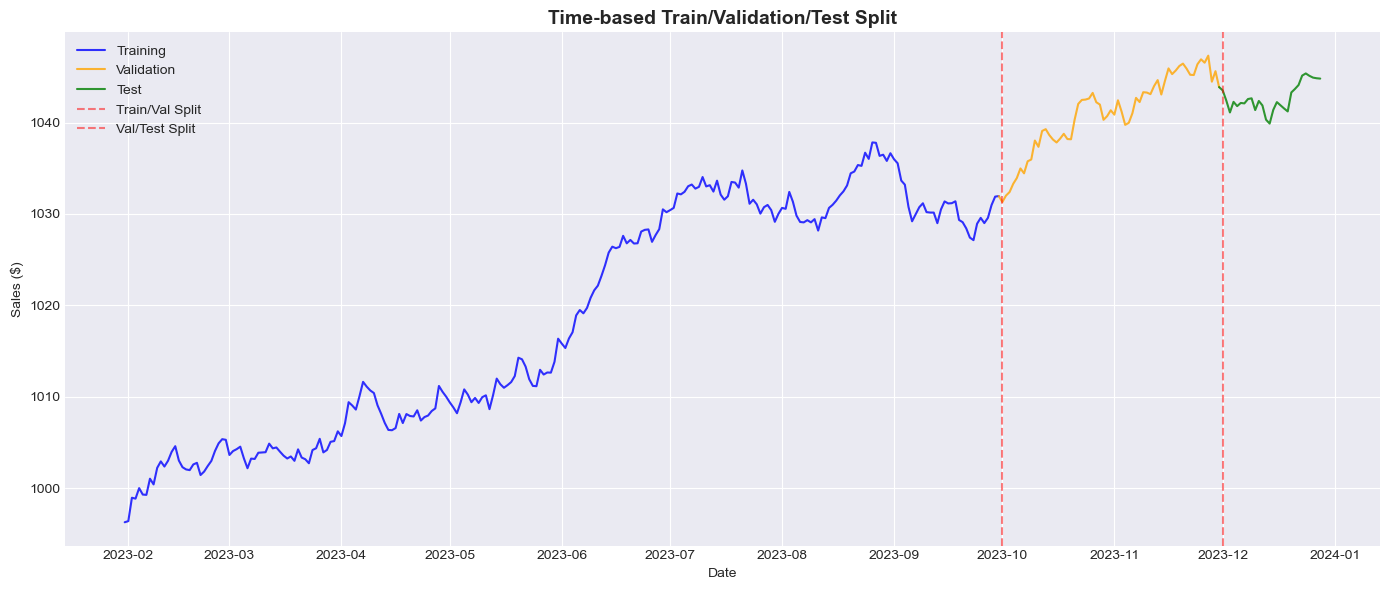


Data leakage check:
Train max date: 2023-09-30 00:00:00
Val min date: 2023-09-30 00:00:00
No overlap: False


In [62]:
# Example 2: Time-based Train/Validation Split
# CRITICAL: Never use random split for time series! Always respect temporal order

def time_series_split(df, train_end_date, val_end_date):
    """Split time series data respecting temporal order"""
    train_data = df[:train_end_date]
    val_data = df[train_end_date:val_end_date]
    test_data = df[val_end_date:]
    return train_data, val_data, test_data

# Split: Train (Jan-Sep), Validation (Oct-Nov), Test (Dec)
train, val, test = time_series_split(df_ml.dropna(), '2023-09-30', '2023-11-30')

print(f"Train set: {train.index[0]} to {train.index[-1]} ({len(train)} days)")
print(f"Validation set: {val.index[0]} to {val.index[-1]} ({len(val)} days)")
print(f"Test set: {test.index[0]} to {test.index[-1]} ({len(test)} days)")

# Visualize the split
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['sales'], label='Training', color='blue', alpha=0.8)
plt.plot(val.index, val['sales'], label='Validation', color='orange', alpha=0.8)
plt.plot(test.index, test['sales'], label='Test', color='green', alpha=0.8)
plt.axvline(x=pd.Timestamp('2023-10-01'), color='red', linestyle='--', alpha=0.5, label='Train/Val Split')
plt.axvline(x=pd.Timestamp('2023-12-01'), color='red', linestyle='--', alpha=0.5, label='Val/Test Split')
plt.title('Time-based Train/Validation/Test Split', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

# Verify no data leakage
print(f"\nData leakage check:")
print(f"Train max date: {train.index.max()}")
print(f"Val min date: {val.index.min()}")
print(f"No overlap: {train.index.max() < val.index.min()}")


Monthly Sales Report:
            sales_sum  sales_mean  sales_std  customers_sum  avg_order_value
2023-01-31   30947.08      998.29       2.44            808            38.30
2023-02-28   28056.06     1002.00       2.14            686            40.90
2023-03-31   31122.74     1003.96       0.84            738            42.17
2023-04-30   30256.86     1008.56       1.58            693            43.66
2023-05-31   31350.55     1011.31       1.89            810            38.70
2023-06-30   30722.39     1024.08       4.54            720            42.67
2023-07-31   31994.86     1032.09       1.36            752            42.55
2023-08-31   32012.38     1032.66       3.06            691            46.33
2023-09-30   30918.75     1030.62       2.03            674            45.87
2023-10-31   32185.77     1038.25       3.43            796            40.43
2023-11-30   31323.44     1044.11       2.13            709            44.18
2023-12-31   32333.62     1043.02       1.73          

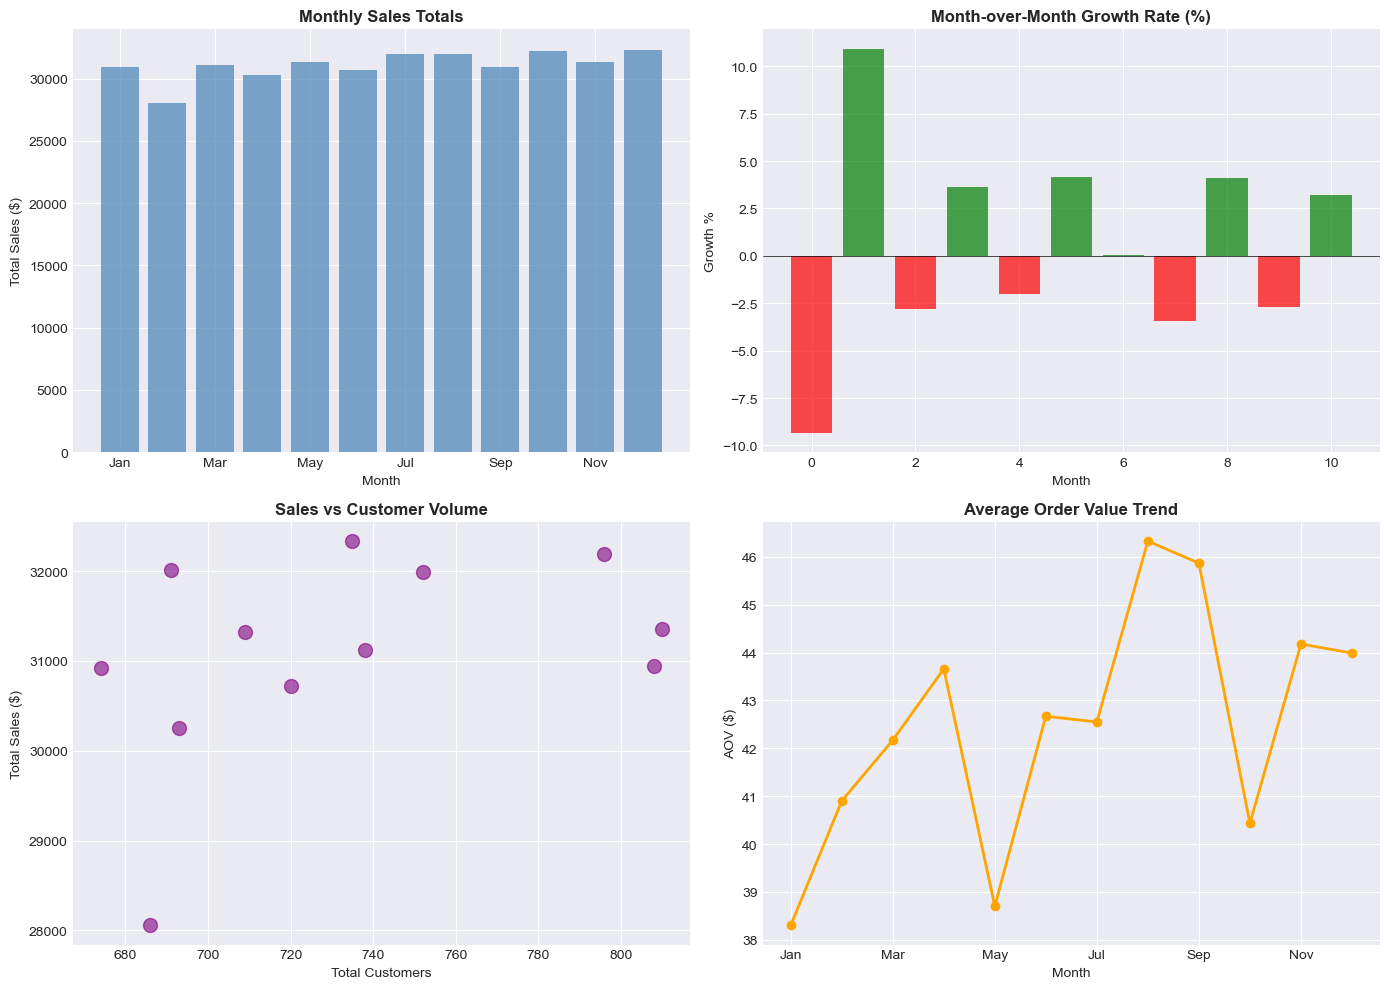

In [63]:
# Example 3: Aggregating daily sales to monthly for reporting
monthly_report = df_sales.resample('ME').agg({
    'sales': ['sum', 'mean', 'std'],
    'customers': 'sum'
}).round(2)

# Flatten column names
monthly_report.columns = ['_'.join(col).strip() for col in monthly_report.columns]
monthly_report['avg_order_value'] = (monthly_report['sales_sum'] / monthly_report['customers_sum']).round(2)

print("Monthly Sales Report:")
print(monthly_report)

# Calculate month-over-month growth
monthly_report['sales_mom_growth'] = monthly_report['sales_sum'].pct_change() * 100
monthly_report['sales_yoy_growth'] = monthly_report['sales_sum'].pct_change(12) * 100  # If we had multiple years

print("\nMonthly Growth Rates:")
print(monthly_report[['sales_sum', 'sales_mom_growth']].head(10))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Monthly totals
axes[0,0].bar(range(len(monthly_report)), monthly_report['sales_sum'], color='steelblue', alpha=0.7)
axes[0,0].set_title('Monthly Sales Totals', fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Total Sales ($)')
axes[0,0].set_xticks(range(0, 12, 2))
axes[0,0].set_xticklabels(['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov'])

# MoM Growth
growth_data = monthly_report['sales_mom_growth'].dropna()
colors = ['green' if x > 0 else 'red' for x in growth_data]
axes[0,1].bar(range(len(growth_data)), growth_data, color=colors, alpha=0.7)
axes[0,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0,1].set_title('Month-over-Month Growth Rate (%)', fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Growth %')

# Sales vs Customers scatter
axes[1,0].scatter(monthly_report['customers_sum'], monthly_report['sales_sum'], 
                  s=100, alpha=0.6, color='purple')
axes[1,0].set_xlabel('Total Customers')
axes[1,0].set_ylabel('Total Sales ($)')
axes[1,0].set_title('Sales vs Customer Volume', fontweight='bold')

# Average order value trend
axes[1,1].plot(range(len(monthly_report)), monthly_report['avg_order_value'], 
               marker='o', linewidth=2, markersize=6, color='orange')
axes[1,1].set_title('Average Order Value Trend', fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('AOV ($)')
axes[1,1].set_xticks(range(0, 12, 2))
axes[1,1].set_xticklabels(['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov'])

plt.tight_layout()
plt.show()


## Hands-On Exercises {#exercises}

Practice each concept below to strengthen your understanding of Pandas time series handling.

### Exercise 1: Convert Strings to Datetime

Convert the following list of date strings into datetime objects using pd.to_datetime(). The values are provided in MM/DD/YYYY format.

In [64]:
date_strings = ['01/15/2024', '02/28/2024', '12/25/2024', '07/04/2024']
# your code here


### Exercise 2: Extract Time Components

Given a datetime Series, extract the year, month, day, and weekday name into separate columns.

In [65]:
dates = pd.date_range('2024-01-01', periods=10, freq='D')
df = pd.DataFrame({'date': dates})
# your code here


### Exercise 3: Set a Datetime Index and Slice Data

Set the date column as the index, then extract all rows from March 2024.

In [66]:
data = pd.DataFrame({
    'date': pd.date_range('2024-01-01', '2024-06-30', freq='D'),
    'value': np.random.randn(182)
})
# your code here


### Exercise 4: Resample a Time Series

Downsample the hourly data into daily averages using .resample().

In [67]:
hourly_data = pd.DataFrame({
    'timestamp': pd.date_range('2024-01-01', periods=168, freq='h'),  # One week
    'temperature': 20 + np.random.randn(168) * 5
})
# your code here


### Exercise 5: Create Rolling Statistics

Calculate the 7-day rolling mean and standard deviation for the sales data.

In [68]:
sales_data = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=60, freq='D'),
    'sales': 1000 + np.cumsum(np.random.randn(60) * 10)
}).set_index('date')
# your code here


### Exercise 6: Generate Lag Features

Create lag-1 and lag-7 features for the temperature data, then calculate the difference between the current value and the lag-7 value.

In [69]:
temp_data = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=30, freq='D'),
    'temperature': 25 + 5 * np.sin(np.arange(30) * 2 * np.pi / 30) + np.random.randn(30)
}).set_index('date')
# your code here


### Exercise 7: Build Time-Based Features for ML

Create the following features from a datetime index: hour, day of week, is_weekend, month, and cyclical hour encoding using sine and cosine.

In [70]:
ml_data = pd.DataFrame({
    'datetime': pd.date_range('2024-01-01', periods=1000, freq='h'),
    'target': np.random.randn(1000)
})
# your code here


### Exercise 8: Time-Aware Train/Test Split

Split the DataFrame into training data (first 80%) and test data (last 20%) without shuffling, while preserving temporal order.

In [71]:
full_data = pd.DataFrame({
    'date': pd.date_range('2023-01-01', periods=365, freq='D'),
    'value': np.cumsum(np.random.randn(365))
}).set_index('date')
# your code here


### Exercise 9: Handle Time Zones

Localize the following timestamps to UTC, then convert them to the Europe/Paris and Asia/Tokyo time zones.

In [72]:
timestamps = pd.to_datetime(['2024-06-15 12:00:00', '2024-12-25 00:00:00', '2024-01-01 06:30:00'])
# your code here


### Exercise 10: Aggregate Daily Data to Monthly

Calculate the sum, mean, and count of daily transactions after aggregating them by month.

In [73]:
transactions = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=120, freq='D'),
    'amount': np.random.randint(10, 1000, 120),
    'customer_id': np.random.randint(1, 50, 120)
}).set_index('date')
# your code here


### Exercise 11: Advanced Feature Engineering

Create a complete feature engineering pipeline that includes lag features (1 day and 7 days), rolling statistics (7-day mean and standard deviation), and time-based features (day of week, month, and is_weekend).

In [74]:
sensor_data = pd.DataFrame({
    'timestamp': pd.date_range('2024-01-01', periods=500, freq='h'),
    'reading': 50 + np.cumsum(np.random.randn(500) * 0.1) + np.sin(np.arange(500) * 2 * np.pi / 24) * 10
}).set_index('timestamp')
# your code here


## Solutions {#solutions}

Review these solutions after attempting the exercises on your own.

### Solution 1: Convert Strings to Datetime

**Instruction:** Convert the following list of date strings into datetime objects using pd.to_datetime(). The values are in MM/DD/YYYY format.

In [75]:
date_strings = ['01/15/2024', '02/28/2024', '12/25/2024', '07/04/2024']
dates = pd.to_datetime(date_strings, format='%m/%d/%Y')
print(dates)
# Expected output: DatetimeIndex(['2024-01-15', '2024-02-28', '2024-12-25', '2024-07-04'], dtype='datetime64[ns]', freq=None)


DatetimeIndex(['2024-01-15', '2024-02-28', '2024-12-25', '2024-07-04'], dtype='datetime64[us]', freq=None)


### Solution 2: Extract Time Components

**Instruction:** Given a datetime Series, extract the year, month, day, and weekday name into separate columns.

In [76]:
dates = pd.date_range('2024-01-01', periods=10, freq='D')
df = pd.DataFrame({'date': dates})
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday_name'] = df['date'].dt.day_name()
print(df)


        date  year  month  day weekday_name
0 2024-01-01  2024      1    1       Monday
1 2024-01-02  2024      1    2      Tuesday
2 2024-01-03  2024      1    3    Wednesday
3 2024-01-04  2024      1    4     Thursday
4 2024-01-05  2024      1    5       Friday
5 2024-01-06  2024      1    6     Saturday
6 2024-01-07  2024      1    7       Sunday
7 2024-01-08  2024      1    8       Monday
8 2024-01-09  2024      1    9      Tuesday
9 2024-01-10  2024      1   10    Wednesday


### Solution 3: Set a Datetime Index and Slice Data

**Instruction:** Set the date column as the index, then extract all rows from March 2024.

In [77]:
data = pd.DataFrame({
    'date': pd.date_range('2024-01-01', '2024-06-30', freq='D'),
    'value': np.random.randn(182)
})
data.set_index('date', inplace=True)
march_data = data.loc['2024-03']
print(f"March 2024 data shape: {march_data.shape}")
print(march_data.head())


March 2024 data shape: (31, 1)
               value
date                
2024-03-01 -2.100829
2024-03-02 -0.080266
2024-03-03 -0.332002
2024-03-04  0.639132
2024-03-05  0.537998


### Solution 4: Resample a Time Series

**Instruction:** Downsample the hourly data into daily averages using .resample().

In [78]:
hourly_data = pd.DataFrame({
    'timestamp': pd.date_range('2024-01-01', periods=168, freq='h'),
    'temperature': 20 + np.random.randn(168) * 5
})
hourly_data.set_index('timestamp', inplace=True)
daily_avg = hourly_data.resample('D').mean()
print(f"Daily averages (7 days):\n{daily_avg}")


Daily averages (7 days):
            temperature
timestamp              
2024-01-01    17.933197
2024-01-02    19.975209
2024-01-03    20.107093
2024-01-04    20.755203
2024-01-05    19.497549
2024-01-06    18.878412
2024-01-07    18.710282


### Solution 5: Create Rolling Statistics

**Instruction:** Calculate the 7-day rolling mean and standard deviation for the sales data.

In [79]:
sales_data = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=60, freq='D'),
    'sales': 1000 + np.cumsum(np.random.randn(60) * 10)
}).set_index('date')
sales_data['rolling_mean_7d'] = sales_data['sales'].rolling(window=7).mean()
sales_data['rolling_std_7d'] = sales_data['sales'].rolling(window=7).std()
print(sales_data[['sales', 'rolling_mean_7d', 'rolling_std_7d']].head(10))


                 sales  rolling_mean_7d  rolling_std_7d
date                                                   
2024-01-01  991.997269              NaN             NaN
2024-01-02  984.419371              NaN             NaN
2024-01-03  970.310895              NaN             NaN
2024-01-04  969.680207              NaN             NaN
2024-01-05  987.961675              NaN             NaN
2024-01-06  976.969764              NaN             NaN
2024-01-07  994.943235       982.326060       10.180367
2024-01-08  997.024401       983.044221       11.111089
2024-01-09  996.095428       984.712229       12.177199
2024-01-10  992.875829       987.935791       10.616116


### Solution 6: Generate Lag Features

**Instruction:** Create lag-1 and lag-7 features for the temperature data, then calculate the difference between the current value and the lag-7 value.

In [80]:
temp_data = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=30, freq='D'),
    'temperature': 25 + 5 * np.sin(np.arange(30) * 2 * np.pi / 30) + np.random.randn(30)
}).set_index('date')
temp_data['temp_lag_1'] = temp_data['temperature'].shift(1)
temp_data['temp_lag_7'] = temp_data['temperature'].shift(7)
temp_data['temp_diff_7'] = temp_data['temperature'] - temp_data['temp_lag_7']
print(temp_data.head(10))


            temperature  temp_lag_1  temp_lag_7  temp_diff_7
date                                                        
2024-01-01    24.897793         NaN         NaN          NaN
2024-01-02    26.271984   24.897793         NaN          NaN
2024-01-03    26.984688   26.271984         NaN          NaN
2024-01-04    26.719825   26.984688         NaN          NaN
2024-01-05    27.243189   26.719825         NaN          NaN
2024-01-06    27.836650   27.243189         NaN          NaN
2024-01-07    30.481537   27.836650         NaN          NaN
2024-01-08    29.152206   30.481537   24.897793     4.254413
2024-01-09    30.441884   29.152206   26.271984     4.169900
2024-01-10    29.842026   30.441884   26.984688     2.857338


### Solution 7: Build Time-Based Features for ML

**Instruction:** Create the following features from a datetime index: hour, day of week, is_weekend, month, and cyclical hour encoding using sine and cosine.

In [81]:
ml_data = pd.DataFrame({
    'datetime': pd.date_range('2024-01-01', periods=1000, freq='h'),
    'target': np.random.randn(1000)
})
ml_data['hour'] = ml_data['datetime'].dt.hour
ml_data['day_of_week'] = ml_data['datetime'].dt.weekday
ml_data['is_weekend'] = (ml_data['day_of_week'] >= 5).astype(int)
ml_data['month'] = ml_data['datetime'].dt.month
ml_data['hour_sin'] = np.sin(2 * np.pi * ml_data['hour'] / 24)
ml_data['hour_cos'] = np.cos(2 * np.pi * ml_data['hour'] / 24)
print(ml_data[['datetime', 'hour', 'day_of_week', 'is_weekend', 'month', 'hour_sin', 'hour_cos']].head())


             datetime  hour  day_of_week  is_weekend  month  hour_sin  \
0 2024-01-01 00:00:00     0            0           0      1  0.000000   
1 2024-01-01 01:00:00     1            0           0      1  0.258819   
2 2024-01-01 02:00:00     2            0           0      1  0.500000   
3 2024-01-01 03:00:00     3            0           0      1  0.707107   
4 2024-01-01 04:00:00     4            0           0      1  0.866025   

   hour_cos  
0  1.000000  
1  0.965926  
2  0.866025  
3  0.707107  
4  0.500000  


### Solution 8: Time-Aware Train/Test Split

**Instruction:** Split the DataFrame into training data (first 80%) and test data (last 20%) without shuffling, while preserving temporal order.

In [82]:
full_data = pd.DataFrame({
    'date': pd.date_range('2023-01-01', periods=365, freq='D'),
    'value': np.cumsum(np.random.randn(365))
}).set_index('date')
train_size = int(len(full_data) * 0.8)
train = full_data.iloc[:train_size]
test = full_data.iloc[train_size:]
print(f"Train: {len(train)} days ({train.index[0]} to {train.index[-1]})")
print(f"Test: {len(test)} days ({test.index[0]} to {test.index[-1]})")


Train: 292 days (2023-01-01 00:00:00 to 2023-10-19 00:00:00)
Test: 73 days (2023-10-20 00:00:00 to 2023-12-31 00:00:00)


### Solution 9: Handle Time Zones

**Instruction:** Localize the following timestamps to UTC, then convert them to the Europe/Paris and Asia/Tokyo time zones.

In [83]:
timestamps = pd.to_datetime(['2024-06-15 12:00:00', '2024-12-25 00:00:00', '2024-01-01 06:30:00'])
df_tz = pd.DataFrame({'timestamp': timestamps})
df_tz['timestamp_utc'] = df_tz['timestamp'].dt.tz_localize('UTC')
df_tz['timestamp_paris'] = df_tz['timestamp_utc'].dt.tz_convert('Europe/Paris')
df_tz['timestamp_tokyo'] = df_tz['timestamp_utc'].dt.tz_convert('Asia/Tokyo')
print(df_tz[['timestamp_utc', 'timestamp_paris', 'timestamp_tokyo']])


              timestamp_utc           timestamp_paris  \
0 2024-06-15 12:00:00+00:00 2024-06-15 14:00:00+02:00   
1 2024-12-25 00:00:00+00:00 2024-12-25 01:00:00+01:00   
2 2024-01-01 06:30:00+00:00 2024-01-01 07:30:00+01:00   

            timestamp_tokyo  
0 2024-06-15 21:00:00+09:00  
1 2024-12-25 09:00:00+09:00  
2 2024-01-01 15:30:00+09:00  


### Solution 10: Aggregate Daily Data to Monthly

**Instruction:** Calculate the sum, mean, and count of daily transactions after aggregating them by month.

In [84]:
transactions = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=120, freq='D'),
    'amount': np.random.randint(10, 1000, 120),
    'customer_id': np.random.randint(1, 50, 120)
}).set_index('date')
monthly_stats = transactions.resample('ME').agg({
    'amount': ['sum', 'mean', 'count'],
    'customer_id': 'nunique'
})
print(monthly_stats)


           amount                   customer_id
              sum        mean count     nunique
date                                           
2024-01-31  12559  405.129032    31          24
2024-02-29  15009  517.551724    29          23
2024-03-31  16423  529.774194    31          26
2024-04-30  14222  490.413793    29          21


### Solution 11: Advanced Feature Engineering

**Instruction:** Create a complete feature engineering pipeline that includes lag features (1 day and 7 days), rolling statistics (7-day mean and standard deviation), and time-based features (day of week, month, and is_weekend).

In [85]:
sensor_data = pd.DataFrame({
    'timestamp': pd.date_range('2024-01-01', periods=500, freq='h'),
    'reading': 50 + np.cumsum(np.random.randn(500) * 0.1) + np.sin(np.arange(500) * 2 * np.pi / 24) * 10
}).set_index('timestamp')

# Lag features
sensor_data['reading_lag_1'] = sensor_data['reading'].shift(1)
sensor_data['reading_lag_7'] = sensor_data['reading'].shift(7)

# Rolling statistics
sensor_data['reading_roll_mean_7'] = sensor_data['reading'].rolling(window=7).mean()
sensor_data['reading_roll_std_7'] = sensor_data['reading'].rolling(window=7).std()

# Time-based features
sensor_data['hour'] = sensor_data.index.hour
sensor_data['day_of_week'] = sensor_data.index.dayofweek
sensor_data['is_weekend'] = (sensor_data['day_of_week'] >= 5).astype(int)
sensor_data['month'] = sensor_data.index.month

print("Engineered features:")
print(sensor_data.columns.tolist())
print("\nSample data:")
print(sensor_data.head(10))


Engineered features:
['reading', 'reading_lag_1', 'reading_lag_7', 'reading_roll_mean_7', 'reading_roll_std_7', 'hour', 'day_of_week', 'is_weekend', 'month']

Sample data:
                       reading  reading_lag_1  reading_lag_7  \
timestamp                                                      
2024-01-01 00:00:00  50.113633            NaN            NaN   
2024-01-01 01:00:00  52.681260      50.113633            NaN   
2024-01-01 02:00:00  55.240382      52.681260            NaN   
2024-01-01 03:00:00  57.443677      55.240382            NaN   
2024-01-01 04:00:00  59.063596      57.443677            NaN   
2024-01-01 05:00:00  60.276871      59.063596            NaN   
2024-01-01 06:00:00  60.460165      60.276871            NaN   
2024-01-01 07:00:00  60.263965      60.460165      50.113633   
2024-01-01 08:00:00  59.238153      60.263965      52.681260   
2024-01-01 09:00:00  57.636298      59.238153      55.240382   

                     reading_roll_mean_7  reading_roll_std_